In [1]:
import glob
import json
import os
import pickle
from collections import defaultdict
from pathlib import Path

import loguru
import numpy as np
import open3d as o3d
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from moma_sg.data.arti4d import load_arti4d_ground_truth
from moma_sg.utils.metrics import pointcloud_iou

GT_DATA_ROOT = Path('../input_data/arti4d/raw')
GT_ARTICULATION, _, _ = load_arti4d_ground_truth(GT_DATA_ROOT)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Listing all gt rooms, scenes, and segments...
Found 8 rooms:
  - din080
  - rh078
  - rh201
  - rr080
  - mhzh
  - imbit-exp
  - hsr
  - mhzh_exo

Scenes:
  - scene_2025-04-11-11-44-32
  - scene_2025-04-11-12-58-58
  - scene_2025-04-11-13-01-59
  - scene_2025-04-11-13-18-00
  - scene_2025-04-11-13-43-03
  - scene_2025-04-11-14-01-06
  - scene_2025-04-11-15-43-24
  - scene_2025-04-11-15-46-48
  - scene_2025-04-04-19-14-38
  - scene_2025-04-04-19-18-54
  - scene_2025-04-07-11-39-17
  - scene_2025-04-07-11-41-52
  - scene_2025-04-07-11-48-40
  - scene_2025-04-09-10-30-11
  - scene_2025-04-09-10-32-52
  - scene_2025-04-09-10-35-47
  - scene_2025-04-09-10-38-38
  - scene_2025-04-09-10-46-48
  - scene_2025-04-09-10-49-20
  - scene_2025-04-24-17-52-21
  - scene_2025-04-24-17-54-13
  - scene_2025-04-24-19-18-42
  - scene_2025-0

In [2]:
def is_within(gt_segment, frame_idx):
    gt_start_frame_idx, gt_end_frame_idx = gt_segment
    return frame_idx >= gt_start_frame_idx and frame_idx <= gt_end_frame_idx


def evaluate_children(gt_hierarchy, pred_hierarchy, name2seg, iou_thresh=0.01):
    """Performs scene-wise children evaluation for a single predicted hierarchy.

    For every GT parent segment, the predicted children whose parent's middle
    frame falls within that segment are matched (greedily, by max IoU) against
    the GT children of that parent. Reports mean IoU, recall (fraction of
    predicted children with IoU >= iou_thresh), and relation-type accuracy.
    """
    iou_across_segments, recall_across_segments, relation_acc_across_segments = [], [], []

    segment_predictions = defaultdict(list)
    for parent_name, gt_children in gt_hierarchy.items():
        gt_segment = name2seg[parent_name]

        for child_idx, child in enumerate(pred_hierarchy["children"]):
            # find the predicted parent this child is attached to via the hierarchy edges
            parent_idx = [edge[0] for edge in pred_hierarchy["edges"] if edge[1] == child_idx]
            if len(parent_idx) == 0:
                continue
            parent_idx = parent_idx[0]
            pred_parent_model = pred_hierarchy["objects"][parent_idx]["model"]
            middle_frame_idx = pred_parent_model.start_idx + (pred_parent_model.end_idx - pred_parent_model.start_idx) // 2
            child["type"] = pred_parent_model.type

            if is_within(gt_segment, middle_frame_idx):
                segment_predictions[parent_name].append(child)

        print(parent_name, len(segment_predictions[parent_name]))

        children_ious, children_recall, relation_acc = [], [], []
        for pred_child in segment_predictions[parent_name]:
            gt_children_iou = []
            for gt_child in gt_children:
                gt_child_points = np.asarray(gt_child['pcd'].points)
                iou = pointcloud_iou(pred_child['points'], gt_child_points, voxel_size=0.015)
                gt_children_iou.append(iou)
            closest_gt_idx = np.argmax(gt_children_iou)
            max_iou = max(gt_children_iou)
            children_ious.append(max_iou)
            relation_acc.append(1 if pred_child["type"].upper() == gt_children[closest_gt_idx]["type"].upper() else 0)
            children_recall.append(1 if max_iou >= iou_thresh else 0)

        iou_across_segments.append(np.mean(children_ious) if len(children_ious) > 0 else 0.0)
        recall_across_segments.append(np.mean(children_recall) if len(children_recall) > 0 else 0.0)
        relation_acc_across_segments.append(np.mean(relation_acc) if len(relation_acc) > 0 else 0.0)

    overall_results = {
        "iou": np.mean(iou_across_segments) if len(iou_across_segments) > 0 else 0.0,
        "recall": np.mean(recall_across_segments) if len(recall_across_segments) > 0 else 0.0,
        "relation_acc": np.mean(relation_acc_across_segments) if len(relation_acc_across_segments) > 0 else 0.0,
    }
    return overall_results


In [ ]:
## Load Moma-SG, Pandora, ArtiPoint results here
METHOD_PATHS = {
    "momasg": Path('/path/to/output_momasg/arti4d/'),
}
CONSIDERED_SPLITS = ['rh201'] # we only evaluate on RH201, not on ['rr080', 'din080', 'rh078']

RESULTS = {}
PREDICTIONS = {}
GT_OBJECTS = {}
GT_HIERARCHY = {}
PARENTS = {}

for room in GT_ARTICULATION.keys():
    if room not in CONSIDERED_SPLITS:
        continue
    RESULTS.setdefault(room, {})
    PREDICTIONS.setdefault(room, {})
    GT_OBJECTS.setdefault(room, {})
    GT_HIERARCHY.setdefault(room, {})
    PARENTS.setdefault(room, {})

    for scene in GT_ARTICULATION[room].keys():
        # if scene not in CONSIDERED_SCENES:
        #     continue
        RESULTS[room].setdefault(scene, {})
        PREDICTIONS[room].setdefault(scene, {})
        GT_OBJECTS[room].setdefault(scene, [])
        GT_HIERARCHY[room].setdefault(scene, {})
        PARENTS[room].setdefault(scene, {})

        gt_segments = []
        seg2name, name2seg = {}, {}
        for _, segment_data in GT_ARTICULATION[room][scene].items():
            gt_segments.append((segment_data.start_time, segment_data.end_time))
            seg2name[(segment_data.start_time, segment_data.end_time)] = segment_data.axis_name
            name2seg[segment_data.axis_name] = (segment_data.start_time, segment_data.end_time)

        print(f'Processing room {room}, scene {scene}')
        gt_children_dir = GT_DATA_ROOT / room / scene / "children"
        gt_parents_dir = GT_DATA_ROOT / room / scene / "parents"
        gt_objects_dir = GT_DATA_ROOT / room / scene / "objects"

        if not gt_children_dir.exists():
            print(f'  No children annotations for {room}/{scene}, skipping.')
            continue

        ### LOAD GT PARENTS
        parent_names = [Path(p).stem.split(".")[0] for p in glob.glob(str(gt_parents_dir / "*.ply"))]
        for parent_name in parent_names:
            gt_parent_ply_path = gt_parents_dir / f"{parent_name}.ply"
            parent_pcd = o3d.io.read_point_cloud(str(gt_parent_ply_path))
            metadata_path = gt_parents_dir / f"{parent_name}.json"
            with open(metadata_path, 'r') as f:
                parent_metadata = json.load(f)
            mask_path = gt_parents_dir / f"{parent_name}_roi_mask.npz"
            parent_data = np.load(mask_path)
            parent_metadata.update({"pcd": parent_pcd, "mask": parent_data["mask"], "axis_name": parent_name})
            frame_idx = parent_metadata["frame_idx"]

            gt_seg_idx = np.argmax([frame_idx > seg[0] and frame_idx < seg[1] for seg in gt_segments])
            PARENTS[room][scene][gt_segments[gt_seg_idx]] = parent_metadata

        ### LOAD GT OBJECTS
        object_names = [Path(p).stem.split(".")[0] for p in glob.glob(str(gt_objects_dir / "*.ply"))]
        for object_name in object_names:
            gt_object_ply_path = gt_objects_dir / f"{object_name}.ply"
            object_pcd = o3d.io.read_point_cloud(str(gt_object_ply_path))
            GT_OBJECTS[room][scene].append({"name": object_name, "pcd": object_pcd})

        ### LOAD GT CHILDREN
        for parent_name in os.listdir(gt_children_dir):
            GT_HIERARCHY[room][scene][parent_name] = []
            children = [Path(p).stem.split(".ply")[0] for p in glob.glob(str(gt_children_dir / parent_name / "*.ply"))]
            for child in children:
                gt_child_ply_path = gt_children_dir / parent_name / f"{child}.ply"
                child_pcd = o3d.io.read_point_cloud(str(gt_child_ply_path))
                metadata_path = gt_children_dir / parent_name / f"{child}-metadata.json"
                with open(metadata_path, 'r') as f:
                    child_metadata = json.load(f)
                mask_path = gt_children_dir / parent_name / f"{child}_mask.npz"
                child_data = np.load(mask_path)
                child_metadata.update({"pcd": child_pcd, "mask": child_data["mask"], "parent_name": parent_name})
                GT_HIERARCHY[room][scene][parent_name].append(child_metadata)

        ### LOAD PREDICTIONS AND EVALUATE
        for method, method_path in METHOD_PATHS.items():
            PREDICTIONS[room][scene][method] = {}

            if method == 'momasg':
                hierarchy_path = method_path / room / scene / "intermediate_results" /"hierarchy.pkl"
            elif method == 'pandora':
                hierarchy_path = method_path / room / scene / "intermediate_results" / "hierarchy.pkl"
            else:
                raise ValueError(f'Unknown method: "{method}"')

            if not hierarchy_path.exists():
                loguru.logger.warning(f"Hierarchy file not found for method {method} in room {room}, scene {scene}. Skipping.")
                continue
            with open(hierarchy_path, 'rb') as f:
                hierarchy_data = pickle.load(f)
            PREDICTIONS[room][scene][method] = hierarchy_data

            loguru.logger.info(
                f"Evaluating {method} predictions for room {room}, scene {scene} with "
                f"{len(hierarchy_data['edges'])} predicted edges and {len(GT_HIERARCHY[room][scene])} GT parents."
            )
            RESULTS[room][scene][method] = evaluate_children(
                GT_HIERARCHY[room][scene],
                hierarchy_data,
                name2seg,
            )


In [11]:
def aggregate_results(RESULTS, method):
    all_results = {}
    for room_results in RESULTS.values():
        for scene_results in room_results.values():
            if method not in scene_results:
                continue
            for k, v in scene_results[method].items():
                all_results.setdefault(k, []).append(v)
    return all_results


for method in METHOD_PATHS.keys():
    print(f"Overall results for method: {method}")
    method_results = aggregate_results(RESULTS, method)
    mean_iou = np.mean(method_results['iou'])
    mean_recall = np.mean(method_results['recall'])
    mean_relation_acc = np.mean(method_results['relation_acc'])
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Mean Recall: {mean_recall:.4f}")
    print(f"Mean Relation Accuracy: {mean_relation_acc:.4f}")
    print("\n")


Overall results for method: momasg
Mean IoU: 0.1114
Mean Recall: 0.4260
Mean Relation Accuracy: 0.9056




In [12]:
evaluated_method = 'momasg'

# Collect per-scene results into a flat list for DataFrame analysis
all_scenes = []
for room, room_data in RESULTS.items():
    for scene, scene_data in room_data.items():
        if evaluated_method not in scene_data:
            continue
        scene_result = dict(scene_data[evaluated_method])
        scene_result['room'] = room
        scene_result['scene'] = scene
        all_scenes.append(scene_result)

df_results = pd.DataFrame(all_scenes)
print(f"Total scenes evaluated: {len(df_results)}")
df_results


Total scenes evaluated: 16


,iou,recall,relation_acc,room,scene
0,0.087264,0.403512,0.857143,rh201,scene_2025-04-25-15-22-54
1,0.093317,0.420000,1.000000,rh201,scene_2025-04-24-19-24-09
2,0.101150,0.400371,0.900000,rh201,scene_2025-04-25-15-19-22
3,0.085541,0.291398,1.000000,rh201,scene_2025-04-25-15-16-29
4,0.084554,0.397959,1.000000,rh201,scene_2025-04-25-10-53-40
5,0.149445,0.525000,0.875000,rh201,scene_2025-04-25-10-36-37
6,0.070991,0.261842,0.666667,rh201,scene_2025-04-25-15-04-48
7,0.085481,0.388928,0.785714,rh201,scene_2025-04-25-11-11-47
8,0.211126,0.658178,1.000000,rh201,scene_2025-04-24-17-54-13
9,0.061803,0.260921,1.000000,rh201,scene_2025-04-25-15-02-14


iou                     recall                    relation_acc  \
        mean median    std count   mean median   std count         mean   
room                                                                      
rh201  0.111   0.09  0.048    16  0.426  0.412  0.13    16        0.906   

                           
      median    std count  
room                       
rh201   0.95  0.113    16

,iou,recall,relation_acc
OVERALL,0.111,0.426,0.906


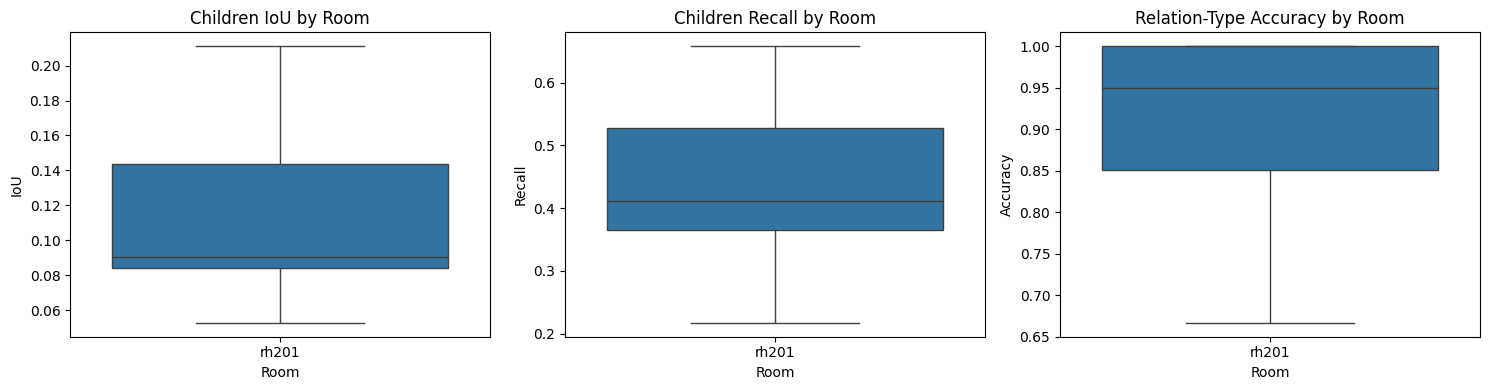

In [13]:
# Per-room aggregate metrics
room_metrics = df_results.groupby('room')[['iou', 'recall', 'relation_acc']].agg(['mean', 'median', 'std', 'count'])
display(room_metrics.round(3))

overall_row = pd.DataFrame([df_results[['iou', 'recall', 'relation_acc']].mean()], index=['OVERALL'])
display(overall_row.round(3))

# Visualize distribution of metrics across scenes
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.boxplot(x='room', y='iou', data=df_results)
plt.title('Children IoU by Room')
plt.xlabel('Room')
plt.ylabel('IoU')

plt.subplot(1, 3, 2)
sns.boxplot(x='room', y='recall', data=df_results)
plt.title('Children Recall by Room')
plt.xlabel('Room')
plt.ylabel('Recall')

plt.subplot(1, 3, 3)
sns.boxplot(x='room', y='relation_acc', data=df_results)
plt.title('Relation-Type Accuracy by Room')
plt.xlabel('Room')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()
